<a href="https://colab.research.google.com/github/Taniice/Analisis-Visitantes-a-Sitios-Arqueologicos/blob/main/Analisis_Visitas_a_Sitios_Arqueologicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Analisis Visitantes a sitios arqueologicos
#INTEGRANTES
# Tania Pamela Apaza Vilca
#Jose Jhonatan Quispe Cartagena

In [2]:
# 1. IMPORTAR LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 2. CONECTAR GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

# 3. CARGAR BASE DE DATOS
ruta = "/content/drive/MyDrive/base de datos sitios_1.csv"

Mounted at /content/drive


In [4]:
#Obtener el dataframe
df = pd.read_csv(ruta, encoding='latin1', sep=';')

In [5]:
#Consultar las filas
print("Primeras filas:")
print(df.head())

#Consultar la información del dataframe
print("\nInformación:")
print(df.info())

# Mostrar resumen estadístico del DataFrame (media, mínimo, máximo, etc.)
print("\nDescripción estadística:")
print(df.describe())

Primeras filas:
   FECHA_CORTE  ANIO  COD_DPTO  NOM_DPTO                            NOM_MUSEO  \
0     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   
1     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   
2     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   
3     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   
4     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   

   COD_MES  NOM_MES  COD_TIPO     NOM_TIPO  ADU_BOLESPPAGANTES  ...  \
0        1    Enero         0   Nacionales                   0  ...   
1        1    Enero         1  Extranjeros                   0  ...   
2        2  Febrero         0   Nacionales                   0  ...   
3        2  Febrero         1  Extranjeros                   0  ...   
4        3    Marzo         0   Nacionales                   0  ...   

   EST_BOLESPNOPAGANTES  NIN_BOLESPNOPAGANTES  MIL_BOLESPNOPAGANTES  \

In [6]:
# 5. LIMPIEZA DE DATOS
# Convertir la columna TOTAL a numérico
df['TOTAL'] = pd.to_numeric(df['TOTAL'], errors='coerce')

# Eliminar valores nulos en TOTAL
df = df.dropna(subset=['TOTAL'])

In [13]:
#cambiamos nombres técnicos a nombres claros y entendibles
#Cambio de JOSE
df = df.rename(columns={
    'FECHA_CORTE': 'fecha',
    'ANIO': 'anio',
    'COD_DPTO': 'cod_departamento',
    'NOM_DPTO': 'departamento',
    'NOM_MUSEO': 'sitio',
    'COD_MES': 'cod_mes',
    'NOM_MES': 'mes',
    'COD_TIPO': 'cod_tipo_visitante',
    'NOM_TIPO': 'tipo_visitante',
    'TOTAL': 'total_visitantes',
    'TOTAL_PAGANTES': 'visitantes_pagantes',
    'TOTAL_NOPAGANTES': 'visitantes_no_pagantes',
    'TIPO_cat_cod': 'categoria'
})

In [15]:
#reorganizamos y filtramos el dataset para dejarlo limpio y listo para el análisis
#cambio de JOSE

df = df[[
    'fecha', 'anio', 'mes',
    'departamento', 'sitio',
    'tipo_visitante',
    'visitantes_pagantes',
    'visitantes_no_pagantes',
    'total_visitantes'
]]

In [16]:
# Convertir fecha de texto o número a fecha real(datetime)
df['fecha'] = pd.to_datetime(df['fecha'], format='%Y%m%d')

# Ordenar datos primero año y luego mes
df = df.sort_values(by=['anio', 'mes'])

# Limpiar textos(normalizar datos)
df['tipo_visitante'] = df['tipo_visitante'].replace({
    'Nacionales': 'Nacional',
    'Extranjeros': 'Extranjero'
})

In [17]:
#reorganizamos los números de la fila del DataFrame
#CAMBIO DE JOSE
df = df.reset_index(drop=True)#evitamos que el indice viejo se convierta en una columna extra
df = df[df['total_visitantes'] >= 0]# evitamos que el índice viejo se convierta en una columna extra

In [18]:
# Convertir columnas a tipo numerico (int o float)
#CAMBIO DE JOSE
cols_numericas = ['total_visitantes', 'visitantes_pagantes', 'visitantes_no_pagantes']

for col in cols_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Eliminar filas con datos clave nulos
df = df.dropna(subset=cols_numericas)#eliminamos columnas con datos nulos

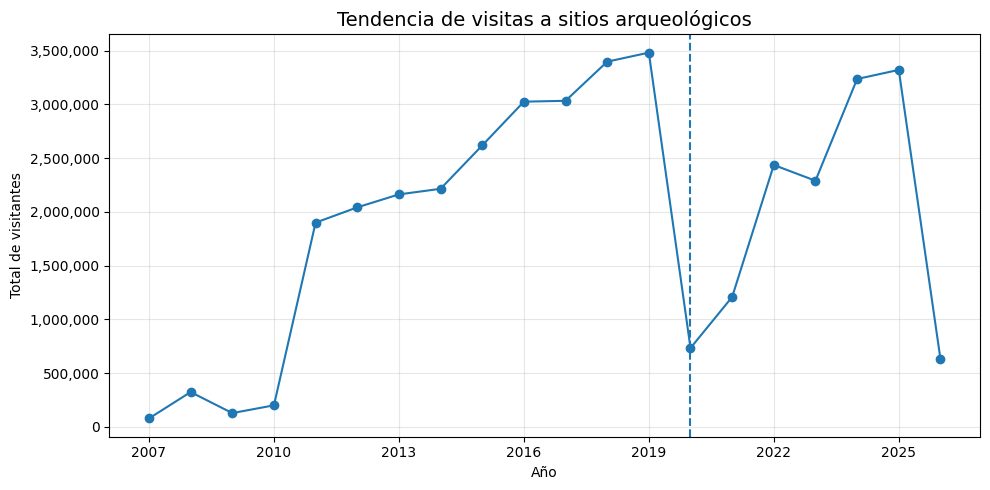

In [20]:
# 6. ANÁLISIS 1: VISITAS POR AÑO
# Asegurar que 'anio' sea entero
df['anio'] = df['anio'].astype(int)

# Agrupar por año(sumanos todos los visitantes por cada año)
visitas_anio = df.groupby('anio')['total_visitantes'].sum()

# Gráfico
plt.figure(figsize=(10,5))
visitas_anio.plot(marker='o') #ponemos puntos en cada año

# Línea vertical en pandemia
plt.axvline(x=2020, linestyle='--')

plt.title("Tendencia de visitas a sitios arqueológicos", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Total de visitantes")
# para no mostrar con decimales
import matplotlib.ticker as ticker

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
# hasta aqui
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

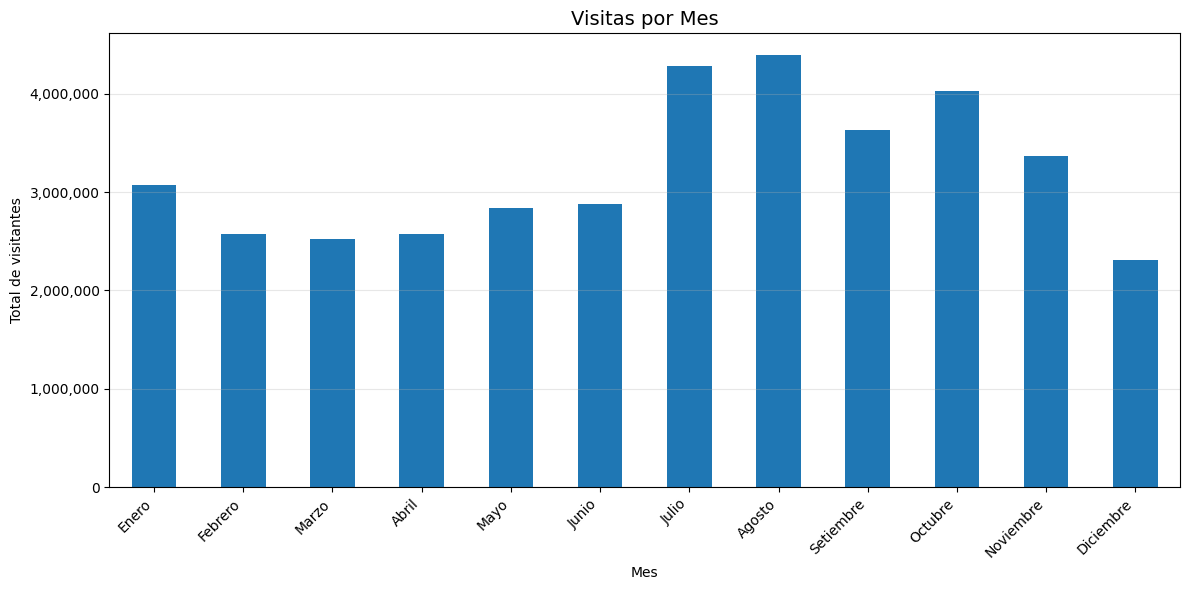

In [33]:
# 7. ANÁLISIS 2: VISITAS POR MES
visitas_mes = df.groupby('mes')['total_visitantes'].sum() #Sumamos los visitantes de cada mes sin importar el año
#deninimos el orden correcto de meses
orden_meses = [
    'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
    'Julio', 'Agosto', 'Setiembre', 'Octubre', 'Noviembre', 'Diciembre'
]

visitas_mes = visitas_mes.reindex(orden_meses) #reordenamos los meses

plt.figure(figsize=(12,6))
visitas_mes.plot(kind='bar')

plt.title("Visitas por Mes", fontsize=14)
plt.xlabel("Mes")
plt.ylabel("Total de visitantes")
#para no mostrar con decimales
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

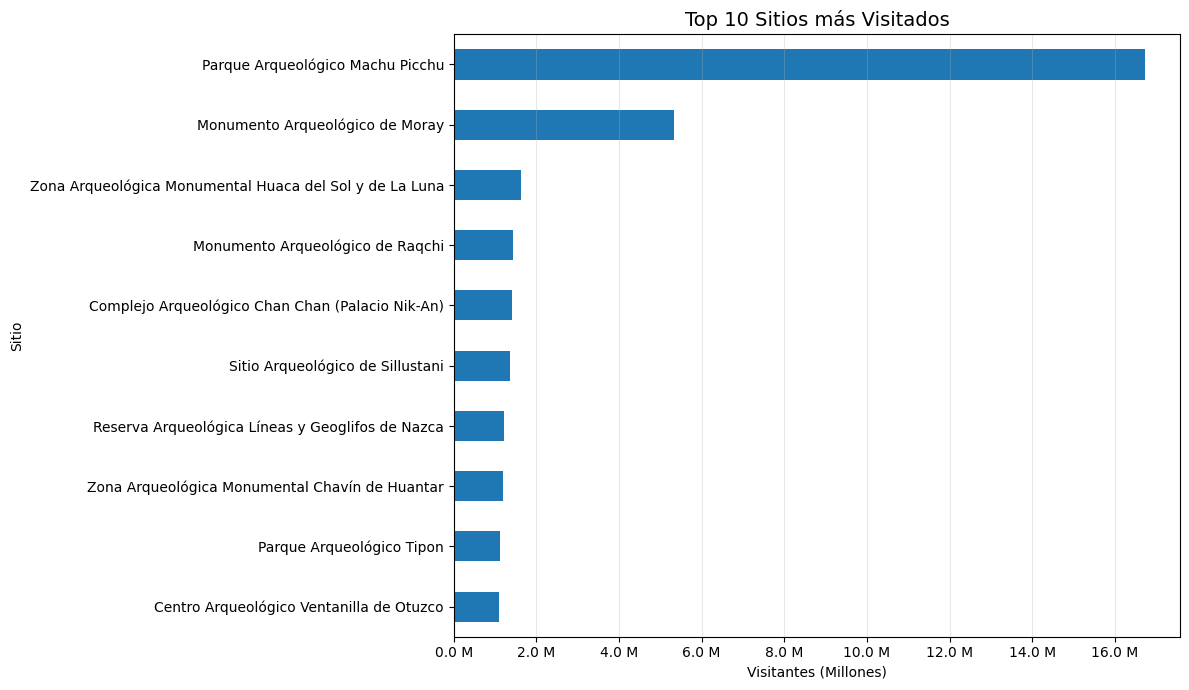

In [32]:
# 8. ANÁLISIS 3: TOP 10 SITIOS
top_sitios = (
    df.groupby('sitio')['total_visitantes']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,7))

top_sitios.sort_values().plot(kind='barh')

plt.title("Top 10 Sitios más Visitados", fontsize=14)
plt.xlabel("Visitantes (Millones)")
plt.ylabel("Sitio")

# Formato en millones
ax = plt.gca()

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f} M')
)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

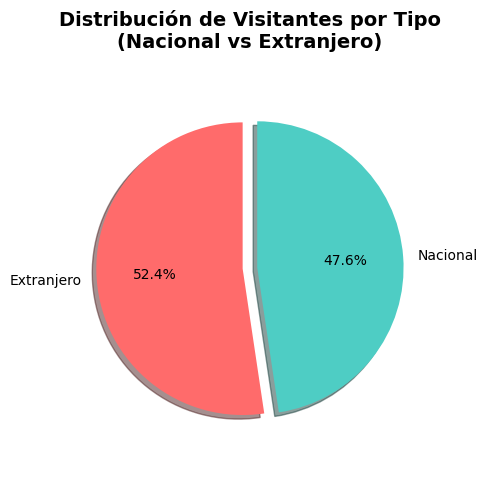

In [49]:
# 9. ANÁLISIS 4: TIPO DE VISITANTE
# (Agrupar por la columna 'tipo_visitante' y sumar los 'visitantes_pagantes')
tipo_visitantes = df.groupby('tipo_visitante')['total_visitantes'].sum()


# Crear el gráfico circular
plt.figure(figsize=(5,5))
plt.pie(tipo_visitantes.values,
        labels=tipo_visitantes.index,
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0.05),  # Separar ligeramente las rebanadas
        shadow=True,
        colors=['#FF6B6B', '#4ECDC4'])  # Colores personalizados

plt.title("Distribución de Visitantes por Tipo\n(Nacional vs Extranjero)",
          fontsize=14,
          fontweight='bold')
plt.ylabel("")  # Eliminar la etiqueta del eje Y
plt.axis('equal')  # Asegurar que el gráfico sea circular
plt.tight_layout()
plt.show()


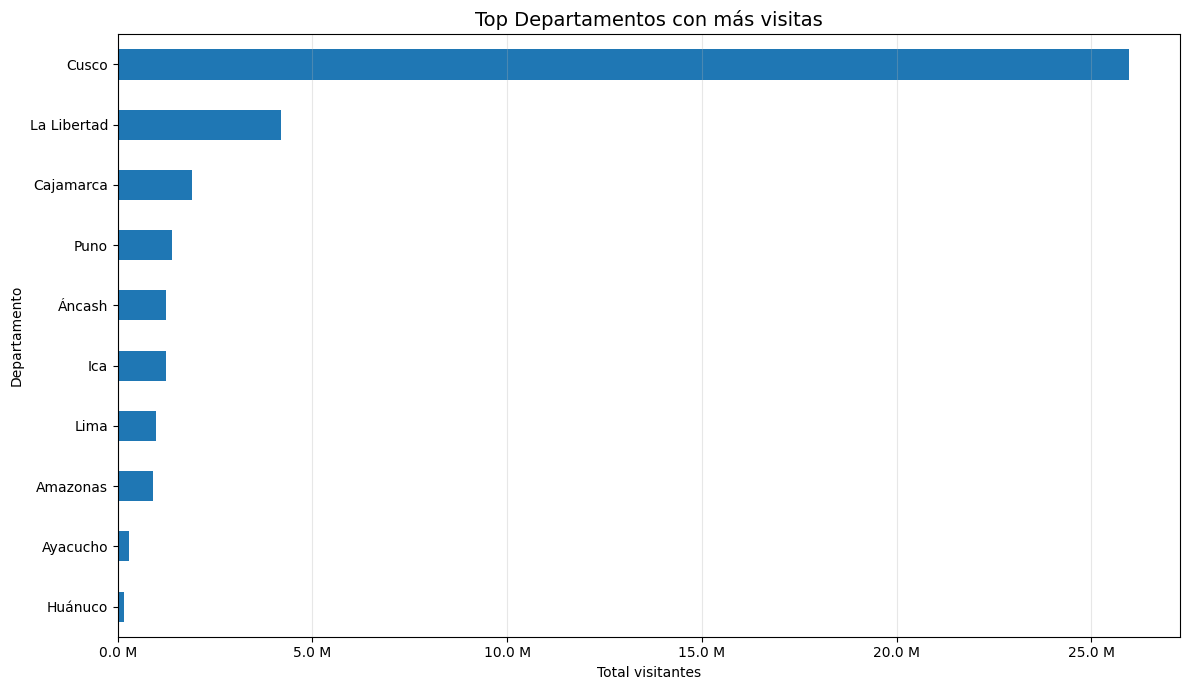


 TOP 10 DEPARTAMENTOS:
--------------------------------------------------
 1. Cusco          :   25,977,558 visitantes
 2. La Libertad    :    4,197,507 visitantes
 3. Cajamarca      :    1,900,762 visitantes
 4. Puno           :    1,384,192 visitantes
 5. Áncash         :    1,243,073 visitantes
 6. Ica            :    1,241,391 visitantes
 7. Lima           :      991,580 visitantes
 8. Amazonas       :      913,980 visitantes
 9. Ayacucho       :      294,556 visitantes
10. Huánuco        :      157,717 visitantes


In [50]:
# 10. ANÁLISIS 5: POR DEPARTAMENTO
plt.figure(figsize=(12,7))
dpto.sort_values().plot(kind='barh') #Ordenamos de menor a mayor usando barras horizontales

plt.title("Top Departamentos con más visitas", fontsize=14)
plt.xlabel("Total visitantes")
plt.ylabel("Departamento")

# Formato en millones
ax = plt.gca()

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f} M')
)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar también los números (opcional)
print("\n TOP 10 DEPARTAMENTOS:")
print("-" * 50)
for i, (depto, visitas) in enumerate(dpto.items(), 1):
    print(f"{i:2d}. {depto:15s}: {visitas:>12,.0f} visitantes")

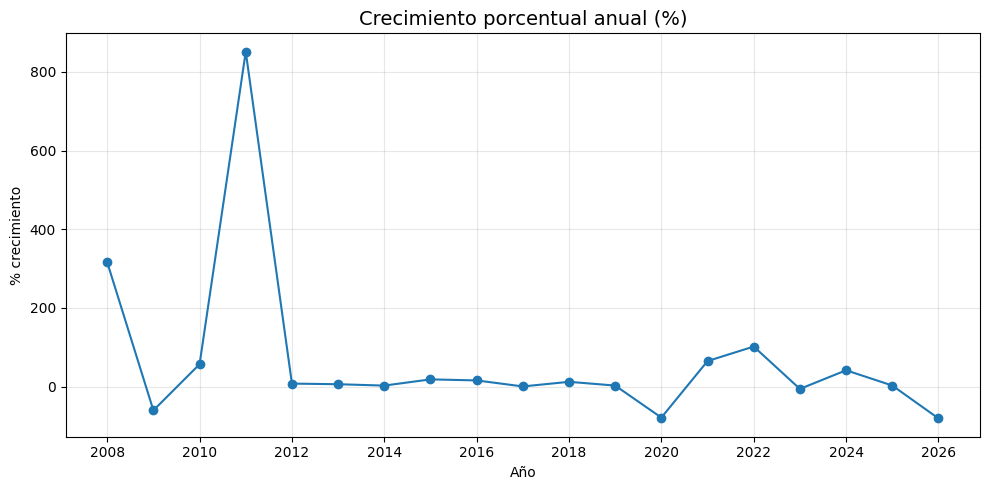

In [59]:
# 11. ANÁLISIS: CRECIMIENTO ANUAL

# Asegurar orden por año (IMPORTANTE)
visitas_anio = visitas_anio.sort_index()

# Calcular crecimiento %
crecimiento = visitas_anio.pct_change() * 100

plt.figure(figsize=(10,5))
crecimiento.plot(marker='o')

#Ponemos a enteros los años
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.title("Crecimiento porcentual anual (%)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("% crecimiento")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
df[df['anio'] == 2010].shape

(122, 9)

In [52]:
df[df['anio'] == 2011].shape

(950, 9)

In [54]:
#Los primeros años presentan menor cantidad de registros disponibles,
#por lo que el incremento observado en 2011 podría estar influenciado
#por cambios en la cobertura de la base de datos.
print(visitas_anuales)

anio
2007      77723
2008     323286
2009     127395
2010     199727
2011    1900292
2012    2042551
2013    2163089
2014    2215249
2015    2618790
2016    3026329
2017    3034266
2018    3398531
2019    3482794
2020     733189
2021    1208205
2022    2436720
2023    2290442
2024    3237356
2025    3321997
2026     632205
Name: total_visitantes, dtype: int64


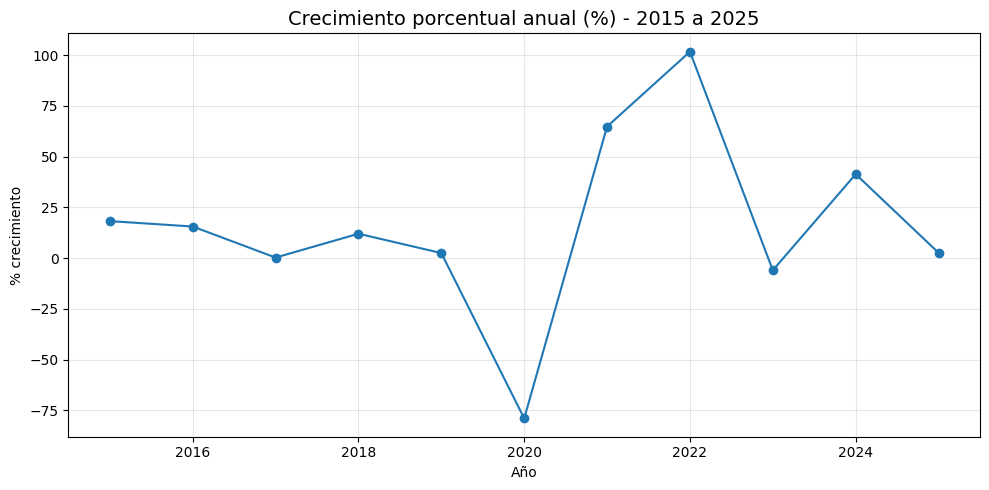

In [57]:
# 11. ANÁLISIS: CRECIMIENTO ANUAL DESDE EL 2015 - 2025
#PARA TENER UNA MEJOR OBSERVACIÓN DEL CRECIMIENTO ANUAL SE PRIOORIZÓ LOS AÑOS 2015 AL 2025, YA QUE EL 2026 aun tienem eses incompletos.

visitas_anio = visitas_anio.sort_index()

# Calcular crecimiento %
crecimiento = visitas_anio.pct_change() * 100

# Filtrar solo años desde 2015 hasta 2025
crecimiento_filtrado = crecimiento.loc[2015:2025]

plt.figure(figsize=(10,5))
crecimiento_filtrado.plot(marker='o')

plt.title("Crecimiento porcentual anual (%) - 2015 a 2025", fontsize=14)
plt.xlabel("Año")
plt.ylabel("% crecimiento")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

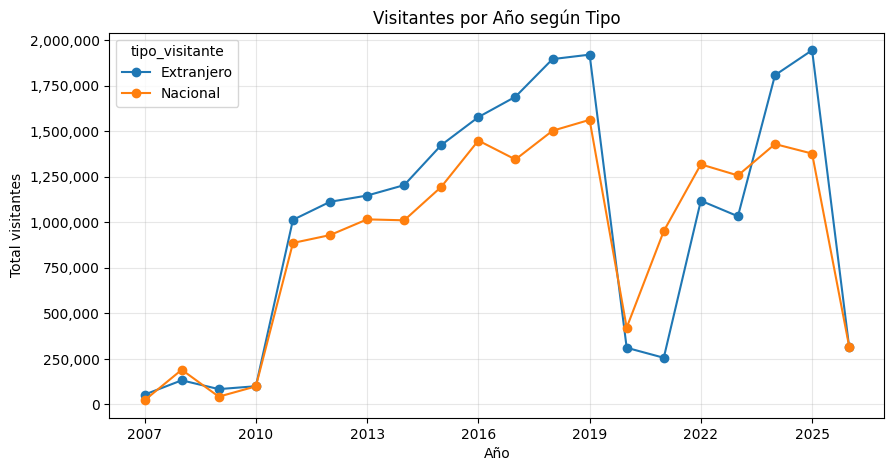

In [60]:
#Comparación de tipo de visitante en el tiempo
tipo_anio = df.groupby(['anio','tipo_visitante'])['total_visitantes'].sum().unstack()

tipo_anio.plot(figsize=(10,5), marker='o')

# para no mostrar con decimales
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title("Visitantes por Año según Tipo")
plt.xlabel("Año")
plt.ylabel("Total visitantes")
plt.grid(alpha=0.3)
plt.show()

anio
2007           NaN
2008    315.946374
2009    -60.593716
2010     56.777739
2011    851.444722
2012      7.486165
2013      5.901346
2014      2.411366
2015     18.216507
2016     15.562111
2017      0.262265
2018     12.005045
2019      2.479395
2020    -78.948252
2021     64.787660
2022    101.681006
2023     -6.003070
2024     41.341977
2025      2.614510
2026    -80.969128
Name: total_visitantes, dtype: float64


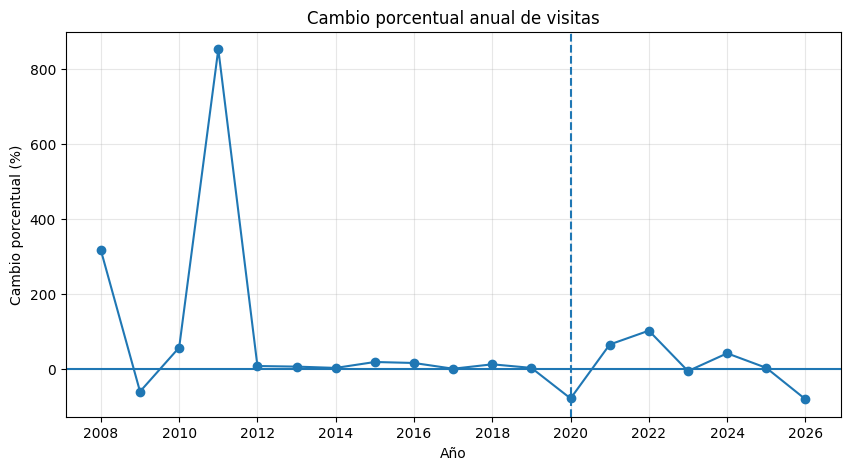

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ==========================================
# VISITAS TOTALES POR AÑO
# ==========================================
visitas_anuales = df.groupby('anio')['total_visitantes'].sum()

# ==========================================
# CAMBIO PORCENTUAL
# ==========================================
cambio_porcentual = visitas_anuales.pct_change() * 100

print(cambio_porcentual)

# ==========================================
# GRÁFICO
# ==========================================
plt.figure(figsize=(10,5))

plt.plot(
    cambio_porcentual.index,
    cambio_porcentual.values,
    marker='o'
)

# Línea horizontal en 0%
plt.axhline(y=0)

# Línea vertical pandemia
plt.axvline(x=2020, linestyle='--')

plt.title('Cambio porcentual anual de visitas')
plt.xlabel('Año')
plt.ylabel('Cambio porcentual (%)')

# Solo enteros en años
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.grid(alpha=0.3)

plt.show()

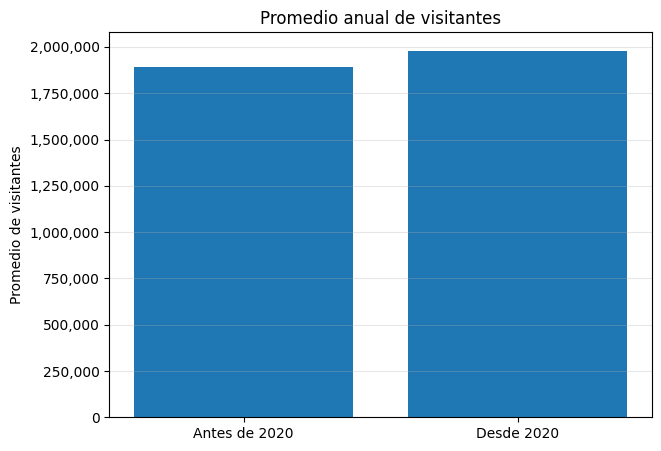

In [36]:
# ==========================================
# SEPARAR PERIODOS
# ==========================================
antes_2020 = df[df['anio'] < 2020]
despues_2020 = df[df['anio'] >= 2020]

# ==========================================
# PROMEDIOS ANUALES
# ==========================================
promedio_antes = antes_2020.groupby('anio')['total_visitantes'].sum().mean()

promedio_despues = despues_2020.groupby('anio')['total_visitantes'].sum().mean()

# ==========================================
# DATOS PARA GRÁFICO
# ==========================================
categorias = ['Antes de 2020', 'Desde 2020']
promedios = [promedio_antes, promedio_despues]

# ==========================================
# GRÁFICO
# ==========================================
plt.figure(figsize=(7,5))

plt.bar(categorias, promedios)

plt.title('Promedio anual de visitantes')
plt.ylabel('Promedio de visitantes')

# Formato bonito
ax = plt.gca()

ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.grid(axis='y', alpha=0.3)

plt.show()

                                                           antes  \
sitio                                                              
Parque Arqueológico Machu Picchu                    45679.766667   
Sitio Arqueológico Huaca Arco Iris (Huaca El Dr...   2282.337963   
Monumento Arqueológico de Raqchi                     4751.986111   
Zona Arqueológica Monumental Huaca del Sol y de...   5302.180556   
Parque Arqueológico Macchu Picchu (Ruta 1: Cami...   3181.856481   
Sitio Arqueológico de Sillustani                     3356.589744   
Sitio Arqueológico Caral                             2544.018519   
Complejo Arqueológico Chan Chan (Palacio Nik-An)     4233.240741   
Paisaje Cultural Arqueológico Cumbemayo              2347.828704   
Zona Arqueológica Monumental El Brujo                2127.533654   

                                                         despues        caida  
sitio                                                                          
Parque Arqueológico Mac

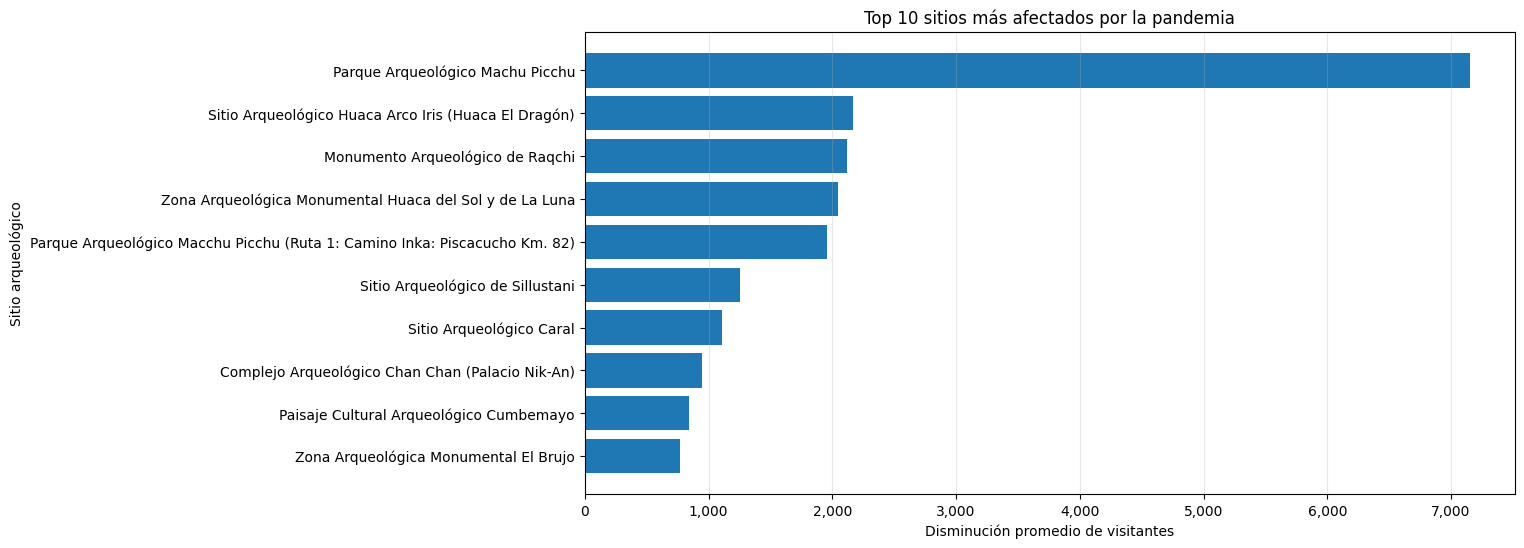

In [37]:
# ==========================================
# VISITAS ANTES DEL 2020
# ==========================================
antes = df[df['anio'] < 2020]

promedio_antes = (
    antes.groupby('sitio')['total_visitantes']
    .mean()
)

# ==========================================
# VISITAS DESDE 2020
# ==========================================
despues = df[df['anio'] >= 2020]

promedio_despues = (
    despues.groupby('sitio')['total_visitantes']
    .mean()
)

# ==========================================
# UNIR DATOS
# ==========================================
comparacion = pd.DataFrame({
    'antes': promedio_antes,
    'despues': promedio_despues
})

# ==========================================
# CALCULAR DIFERENCIA
# ==========================================
comparacion['caida'] = (
    comparacion['antes'] - comparacion['despues']
)

# ==========================================
# TOP 10 MÁS AFECTADOS
# ==========================================
top_afectados = comparacion.sort_values(
    by='caida',
    ascending=False
).head(10)

print(top_afectados)

# ==========================================
# GRÁFICO
# ==========================================
plt.figure(figsize=(12,6))

plt.barh(
    top_afectados.index,
    top_afectados['caida']
)

plt.title('Top 10 sitios más afectados por la pandemia')
plt.xlabel('Disminución promedio de visitantes')
plt.ylabel('Sitio arqueológico')

# Formato bonito
ax = plt.gca()

ax.xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3)

plt.show()